## Question 1 — Fiabilité des jugements humains 

### Accord sur le signal "creative"

In [ ]:
import pandas as pd

df_reactions = pd.read_parquet(
    'comparia-reactions/reactions.parquet',
    engine='pyarrow',
    dtype_backend="numpy_nullable"
)

In [2]:
pd.set_option("display.max_columns", 40)

In [3]:
df_reactions.head()

,id,timestamp,model_a_name,model_b_name,refers_to_model,msg_index,opening_msg,conversation_a,conversation_b,model_pos,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,refers_to_conv_id,session_hash,visitor_id,response_content,question_content,liked,disliked,comment,useful,creative,complete,clear_formatting,incorrect,superficial,instructions_not_followed,model_pair_name,msg_rank,question_id,system_prompt
0,202099,2025-04-23 19:32:46.687338,gemma-3-12b,command-a,command-a,1,Quelle est la stratégie commerciale du champag...,[{'content': 'Quelle est la stratégie commerci...,[{'content': 'Quelle est la stratégie commerci...,b,1,1a62544c50474085b25240991e9fc620-6e6ffca415f44...,1a62544c50474085b25240991e9fc620,6e6ffca415f44bb88b781ec37b843420,6e6ffca415f44bb88b781ec37b843420,yl3mcxcqmz,64cfc81ae363a8abc31eaeff5387439f,La stratégie commerciale de **Champagne Nicola...,Quelle est la stratégie commerciale du champag...,True,False,,False,False,True,False,False,False,False,"[command-a, gemma-3-12b]",0,1a62544c50474085b25240991e9fc620-6e6ffca415f44...,<NA>
1,176467,2025-03-25 13:41:21.988182,llama-3.1-8b,claude-3-5-sonnet-v2,llama-3.1-8b,1,Qui est président en France ?,"[{'content': 'Qui est président en France ?', ...","[{'content': 'Qui est président en France ?', ...",a,1,ba089364a6e64d14b80eae6f7dd1885f-cda152aa7fe04...,ba089364a6e64d14b80eae6f7dd1885f,cda152aa7fe049f9ae0e02379f01f342,ba089364a6e64d14b80eae6f7dd1885f,4x178smu9v,3d3720ea8c5ff9dfbdbc886bd7ee7d00,Le président de la République française est ac...,Qui est président en France ?,True,False,,False,False,True,False,False,False,False,"[claude-3-5-sonnet-v2, llama-3.1-8b]",0,ba089364a6e64d14b80eae6f7dd1885f-cda152aa7fe04...,<NA>
2,231166,2025-06-03 15:38:11.580715,gpt-4.1-nano,llama-4-scout,llama-4-scout,1,tests logiciel,"[{'content': 'tests logiciel', 'metadata': Non...","[{'content': 'tests logiciel', 'metadata': Non...",b,1,e46e59300e8545038bfc22dfffb0b746-b006443eb1564...,e46e59300e8545038bfc22dfffb0b746,b006443eb1564f49b98a41b62b1078b3,b006443eb1564f49b98a41b62b1078b3,mwupf5ht3kr,bb1f75dbd09bcd96a6a2a95790c32f5c,Les tests logiciels ! Voici une vue d'ensemble...,tests logiciel,True,False,,False,False,True,False,False,False,False,"[gpt-4.1-nano, llama-4-scout]",0,e46e59300e8545038bfc22dfffb0b746-b006443eb1564...,<NA>
3,264589,2025-08-20 13:52:02.676745,llama-3.1-405b,mistral-large-2411,llama-3.1-405b,13,Vols au meilleur prix au départ de Marseille p...,[{'content': 'Vols au meilleur prix au départ ...,[{'content': 'Vols au meilleur prix au départ ...,a,9,1f181e340b664f88b1aacc6770d0eeff-3f295419957c4...,1f181e340b664f88b1aacc6770d0eeff,3f295419957c465cb4c8713c5b600351,1f181e340b664f88b1aacc6770d0eeff,3bwjdjdu4gu,1299d615674a3add049c9869cf9eac1b,Le musée Harry Potter est un lieu de visite tr...,Intégrer la visite du musée Harry Potter dans ...,True,False,,True,False,False,False,False,False,False,"[llama-3.1-405b, mistral-large-2411]",6,1f181e340b664f88b1aacc6770d0eeff-3f295419957c4...,<NA>
4,203152,2025-04-25 20:40:31.489534,o4-mini,claude-3-7-sonnet,o4-mini,1,Comporte toi comme un expert en rédaction de p...,[{'content': 'Comporte toi comme un expert en ...,[{'content': 'Comporte toi comme un expert en ...,a,1,5a646fd23c7c480dbbb9dac5f50b8c6d-5d343345ef294...,5a646fd23c7c480dbbb9dac5f50b8c6d,5d343345ef29439f915cbf3b3e9f82a6,5a646fd23c7c480dbbb9dac5f50b8c6d,yjz4oi5uzk,36ffd7b8de35fe20f4850fa9f45d88e1,Bonjour à toutes et à tous. \n\nImaginez un vo...,Comporte toi comme un expert en rédaction de p...,False,True,,False,False,False,False,False,True,False,"[claude-3-7-sonnet, o4-mini]",0,5a646fd23c7c480dbbb9dac5f50b8c6d-5d343345ef294...,<NA>


In [4]:
df_reactions[["conversation_pair_id", "msg_index"]].nunique()

conversation_pair_id    53462
msg_index                  77
dtype: int64

In [5]:
df_reactions.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'refers_to_model',
       'msg_index', 'opening_msg', 'conversation_a', 'conversation_b',
       'model_pos', 'conv_turns', 'conversation_pair_id', 'conv_a_id',
       'conv_b_id', 'refers_to_conv_id', 'session_hash', 'visitor_id',
       'response_content', 'question_content', 'liked', 'disliked', 'comment',
       'useful', 'creative', 'complete', 'clear_formatting', 'incorrect',
       'superficial', 'instructions_not_followed', 'model_pair_name',
       'msg_rank', 'question_id', 'system_prompt'],
      dtype='object')

#### Taux d'accord brut sur la créativité

In [6]:
group_cols = ["conversation_pair_id", "msg_index"]

df_counts = df_reactions.groupby(group_cols)["creative"].agg(
    n="count",
    agreement=lambda x: x.nunique() == 1  # si tous identiques
).reset_index()

df_valid = df_counts[df_counts["n"] >= 2] # ne garde seulement les groupes où il y a au moins deux réactions

raw_agreement_rate = df_valid["agreement"].mean() # taux d'agreement
print("Accord brut creative:", raw_agreement_rate)

del df_valid
del df_counts

Accord brut creative: 0.9051282837262055


On observe un taux d'accord brut sur la créativité de 90,5 %

In [7]:
print(df_reactions['creative'].value_counts())

print(df_reactions['useful'].value_counts())

print(df_reactions['complete'].value_counts())

creative
False    87424
True      6354
Name: count, dtype: Int64
useful
False    71402
True     22376
Name: count, dtype: Int64
complete
False    75801
True     18493
Name: count, dtype: Int64


Cependant ce taux d'accord est biaisé par la forte disparité entre les labels vrai et faux sur cette classe. De même useful et complete présentent une disparité. Il est donc intéressant de s'intéresser à d'autres mesures afin de pouvoir interpréter cela.

#### K de Cohen + hypothèses

In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np



creative = [[], []]
useful = [[], []]
complete = [[], []]

def compute_pairwise_kappa(df, label):
    pairs = []
    
    # enlever les nan sur la colonne
    df_filtered = df.dropna(subset=label)    
    
    pivot = (
    df_filtered
    .groupby(["conversation_pair_id", "msg_index"])
    .filter(lambda g: len(g) == 2)
    .assign(a=lambda x: x.groupby(["conversation_pair_id", "msg_index"]).cumcount())
    .pivot(index=["conversation_pair_id", "msg_index"], columns="a", values=label)
)

    y1, y2 = pivot[0].astype(int), pivot[1].astype(int)
    
    return cohen_kappa_score(y1, y2)
    

kappa_creative = compute_pairwise_kappa(df_reactions, "creative")
kappa_useful = compute_pairwise_kappa(df_reactions, "useful")
kappa_complete = compute_pairwise_kappa(df_reactions, "complete")

print("Kappa creative:", kappa_creative)
print("Kappa useful:", kappa_useful)
print("Kappa complete:", kappa_complete)

Kappa creative: 0.20025765679138596
Kappa useful: 0.30484376738491903
Kappa complete: 0.13346447252027882


Les Kappa obtenus sont globalement faibles, indiquant un accord limité entre annotateurs.

Le label useful présente le Kappa le plus élevé (0.30), suggérant qu’il est relativement mieux défini et plus consensuel.

À l’inverse, complete obtient le Kappa le plus faible (0.13), ce qui reflète une forte subjectivité et un manque d’homogénéité dans son interprétation.

Le label creative se situe entre les deux, avec un accord faible (0.20), confirmant son caractère également subjectif.

Ces résultats suggèrent que la qualité des annotations dépend fortement de la clarté du critère, useful étant le plus robuste, creative étant subjectif et complete peut être mal défini.

A REGARDER

In [9]:
group_sizes = df_reactions.groupby(group_cols).size()
group_sizes.value_counts()

2    32786
1    28722
Name: count, dtype: int64

In [10]:
del df_reactions

### Biais de sélection des votants

CONVERSATIONS

In [ ]:
import pandas as pd

df_conv = pd.read_parquet(
    'comparia-conversations/conversations.parquet',
    engine='pyarrow',
    dtype_backend="numpy_nullable"
)

df_conv.head()

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,session_hash,visitor_id,model_pair_name,opening_msg,system_prompt_a,system_prompt_b,mode,custom_models_selection,short_summary,keywords,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
0,1562219,2026-03-06 19:37:04.399632,gemini-3.1-pro-preview,claude-4-6-sonnet,[{'content': 'Comment protéger les métiers art...,[{'content': 'Comment protéger les métiers art...,1,14edd982fc504dbe9835702fa2127ea5-1b4887d008ba4...,14edd982fc504dbe9835702fa2127ea5,1b4887d008ba47ac8ecba23600dcb4cf,934e7178-476f-406d-a0e7-acdfd8d3e24b,5ddc8517e4630de952fa033d8a54f73a,"{claude-4-6-sonnet,gemini-3.1-pro-preview}",Comment protéger les métiers artistiques tout ...,<NA>,<NA>,custom,"[claude-4-6-sonnet, gemini-3.1-pro-preview]",The conversation discusses protecting artistic...,"[artistic professions, artificial intelligence...","[Arts, Law & Justice, Business & Economics & F...",[fr],1596,1000,750.0,440.0,45.0,137.0,0.006846,0.003931
1,1562216,2026-03-06 19:35:14.874855,DeepSeek-V3.2,mistral-large-2512,[{'content': 'Cet extrait de L'Amant de Margue...,[{'content': 'Cet extrait de L'Amant de Margue...,1,dbe0a97393c944d7bbc0a2c8ed41fc2c-e9c80e780cc04...,dbe0a97393c944d7bbc0a2c8ed41fc2c,e9c80e780cc04a7799188076bebba660,06fc6f1c-bf3e-42dd-af9a-0d79fff9a952,25fe7f5ba6e79e36643d237471a840e4,"{DeepSeek-V3.2,mistral-large-2512}",Cet extrait de L'Amant de Marguerite Duras se ...,<NA>,<NA>,custom,"[DeepSeek-V3.2, mistral-large-2512]",An analysis of a passage from Marguerite Duras...,"[Marguerite Duras, L'Amant, Chopin, valse, nar...","[Education, Arts, Culture & Cultural geography]",[fr],1829,2059,685.0,675.0,37.0,41.0,0.007277,0.008512
2,1553428,2026-03-05 11:04:09.160544,gpt-5-mini,Apertus-70B-Instruct-2509,[{'content': 'Quelle est la capitale de la Fra...,[{'content': 'Quelle est la capitale de la Fra...,1,8100c7848ee14997bc6248bc76bb8ff9-3afec45a9a374...,8100c7848ee14997bc6248bc76bb8ff9,3afec45a9a374ddbb7ca0652c50b8e0b,2b232817-36f3-4c91-90b7-cd899b3ee934,c84f9b5a449326a39cd15b21d2416a1f,"{Apertus-70B-Instruct-2509,gpt-5-mini}",Quelle est la capitale de la France ?\nb) Quel...,<NA>,<NA>,custom,"[Apertus-70B-Instruct-2509, gpt-5-mini]",A user asks a series of questions about variou...,"[France capital, Wi-Fi speed, solar panel, mic...",[Natural Science & Formal Science & Technology...,[fr],0,0,47.0,70.0,47.0,70.0,0.0,0.0
3,1562222,2026-03-06 19:37:42.727688,gemma-3-27b,qwen3-coder-next,[{'content': 'Ecrit moi un roman très très trè...,[{'content': 'Ecrit moi un roman très très trè...,0,4246bbb60ba9498eba23fd22ca443434-b55bf215f4ac4...,4246bbb60ba9498eba23fd22ca443434,b55bf215f4ac4494a0baf94952762be5,6c2c409f-14e1-4c31-ab20-e05f94c8dc6c,444ffa14c83f995f4227a4a9bf395b21,"{gemma-3-27b,qwen3-coder-next}",Ecrit moi un roman très très très très érotiqu...,<NA>,<NA>,random,[],A user requests the generation of a long and d...,"[novel, necklace, student, adventure, wind, sw...","[Entertainment & Travel & Hobby, Arts, Other]",[fr],0,0,27.0,80.0,27.0,3.0,0.0,0.0
4,1584150,2026-03-11 12:37:45.876836,Apertus-70B-Instruct-2509,mistral-medium-2508,[{'content': 'Tu es scientifiques en sciences ...,[{'content': 'Tu es scientifiques en sciences ...,1,58250d72e17945dfb26fa3c266f1e08b-857baa84a5554...,58250d72e17945dfb26fa3c266f1e08b,857baa84a5554d788cc5a8d29427cde9,0e019774-7688-4811-b424-f8a98bacaba8,fc56866e083476414e83d6f9e3c7f278,"{Apertus-70B-Instruct-2509,mistral-medium-2508}",Tu es scientifiques en sciences humaines et tu...,<NA>,<NA>,random,[],The assistant provides a list of relevant peop...,"[bande dessinée, contemporary, German comics, ...","[Arts, Education, Culture & Cultural geography]",[fr],674,2206,70.0,123.0,70.0,123.0,0.000443,0.002018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [ ]:
import pandas as pd

df_votes = pd.read_parquet(
    'comparia-votes/votes.parquet',
    engine='pyarrow',
    dtype_backend="numpy_nullable"
)

df_votes.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,conv_turns,selected_category,is_unedited_prompt,conversation_pair_id,session_hash,visitor_id,conv_comments_a,conv_comments_b,conv_useful_a,conv_useful_b,conv_creative_a,conv_creative_b,conv_clear_formatting_a,conv_clear_formatting_b,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",<NA>,crée des cartes types dixit sur le thème des m...,True,[{'content': 'crée des cartes types dixit sur ...,[{'content': 'crée des cartes types dixit sur ...,2,<NA>,False,2bd61e83f28f4b4b8194d818f4a04505-d3d7b1a7c0944...,bfsfi12kqtn,fc56866e083476414e83d6f9e3c7f278,,,False,False,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,False,[{'content': 'J'ai lu quelque part (je ne sais...,[{'content': 'J'ai lu quelque part (je ne sais...,11,<NA>,False,8a15faf5c5374cc1bbbc84426a8bc0e6-e4ed6e033a844...,ckjk99qfvl8,9b818e46ca74b660146b4a05075e56e7,,,True,True,False,False,True,True,False,False,False,True,False,False,<NA>,<NA>,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",<NA>,créer un texte sur le degrés d'intégration des...,True,[{'content': 'créer un texte sur le degrés d'i...,[{'content': 'créer un texte sur le degrés d'i...,1,<NA>,False,02a1beb885d6437b9aaf86ca2150cada-72440d05cd4b4...,5cnmcat72jc,c33091ad79ff386d618d4f14cdecd242,,,True,True,False,False,True,True,False,False,False,False,False,False,<NA>,<NA>,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,False,"[{'content': 'Coucou ', 'metadata': None, 'rea...","[{'content': 'Coucou ', 'metadata': None, 'rea...",1,<NA>,False,573f0e72a1224bf593b4a3e99ec84cc1-a38898e3fede4...,ch2oclz234w,e85c39f65f08cd06257f57c8f5035181,,,False,False,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,False,[{'content': 'Tu es un assistant IA serviable ...,[{'content': 'Je souhaite élaborer des routine...,1,<NA>,False,765ed4394730412080786719f230d9f4-c4ea6d3ea0724...,lgq16bamoz,1c921335a2cc49ccaa0a54d4cd92faa1,,,False,False,False,False,False,False,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False


In [13]:
# On sélectionne le sous ensemble des conversations votées

df_conv_voted = df_conv[df_conv['conversation_pair_id'].isin(df_votes['conversation_pair_id'])]
len(df_conv_voted)

153062

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_and_get_stats(numcol):
    
    def summary_stats(df, col):
        return pd.Series({
            "mean": df[col].mean(),
            "median": df[col].median(),
            "p75": df[col].quantile(0.75),
            "p90": df[col].quantile(0.90)
        })

    print(f"==== COLONNE {numcol} ====")

    summary_v = summary_stats(df_conv_voted, numcol)
    summary_nv = summary_stats(df_conv, numcol)

    df_summary = pd.DataFrame({
        "voted": summary_v,
        "not_voted": summary_nv
    })

    
    print(df_summary)



    sns.kdeplot(df_conv_voted[numcol], label="voted")
    sns.kdeplot(df_conv[numcol], label="not voted")
    plt.xscale("log")
    plt.legend()
    plt.show()

==== COLONNE conv_turns ====
           voted  not_voted
mean    1.339607   1.369618
median  1.000000   1.000000
p75     1.000000   1.000000
p90     2.000000   2.000000


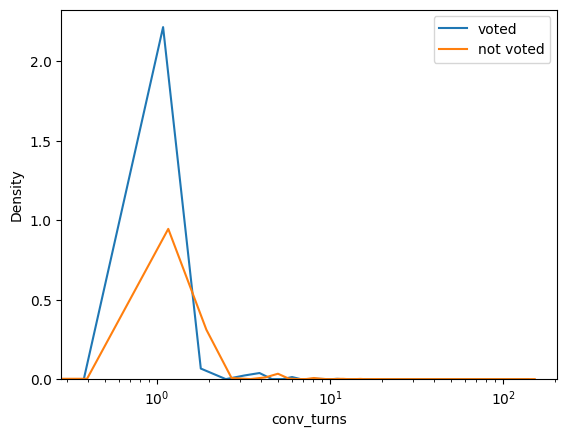

==== COLONNE total_conv_a_output_tokens ====
              voted   not_voted
mean    1029.523559  1012.43681
median   735.000000   627.00000
p75     1260.000000  1208.00000
p90     2120.000000  2208.00000


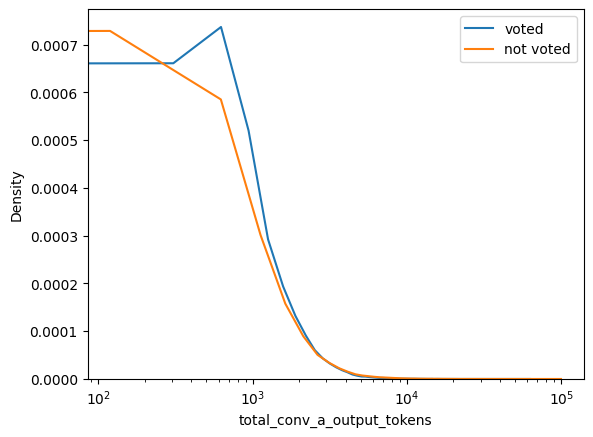

==== COLONNE total_conv_b_output_tokens ====
              voted   not_voted
mean    1026.616659  1009.43834
median   734.000000   628.00000
p75     1255.750000  1207.00000
p90     2111.000000  2207.00000


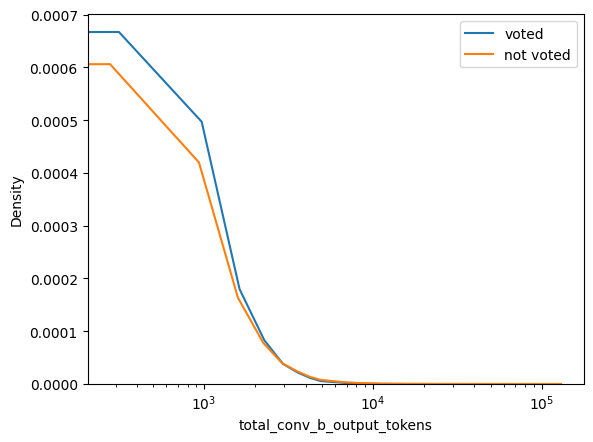

In [20]:
plot_and_get_stats('conv_turns')
plot_and_get_stats('total_conv_a_output_tokens')
plot_and_get_stats('total_conv_b_output_tokens')

Les distributions et statistiques classiques sur le nombre de turns et de token sont relativement similaire. A ce niveau là, les conversations votées sont représentatives du corpus total.

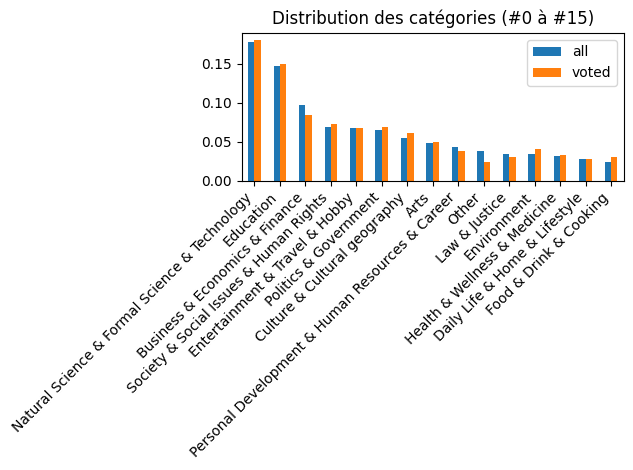

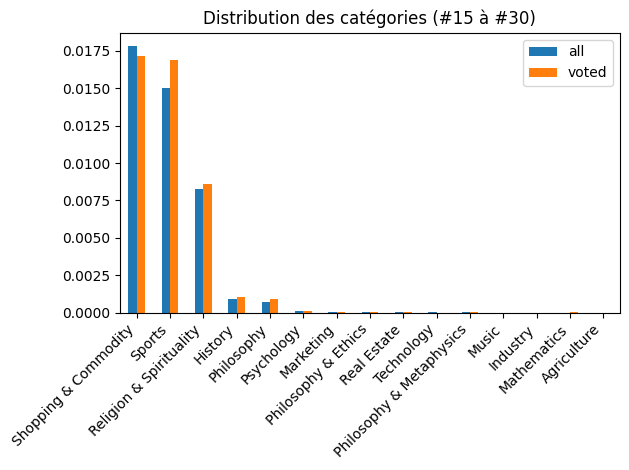

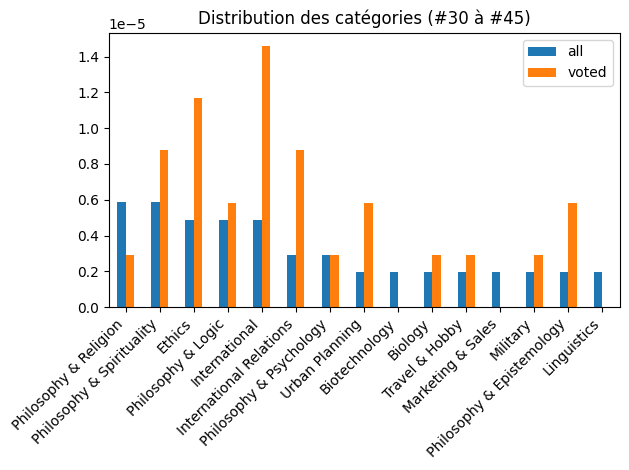

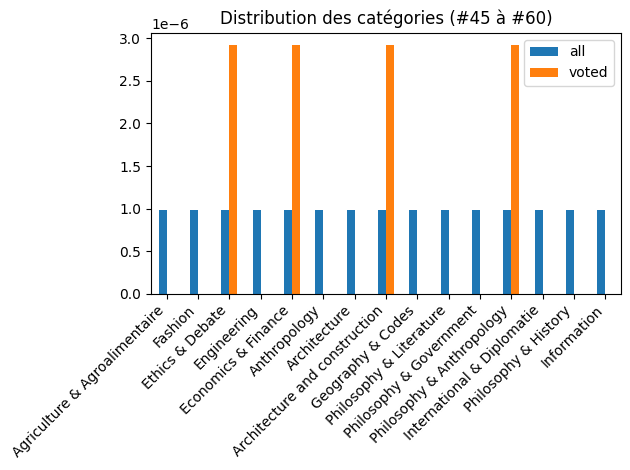

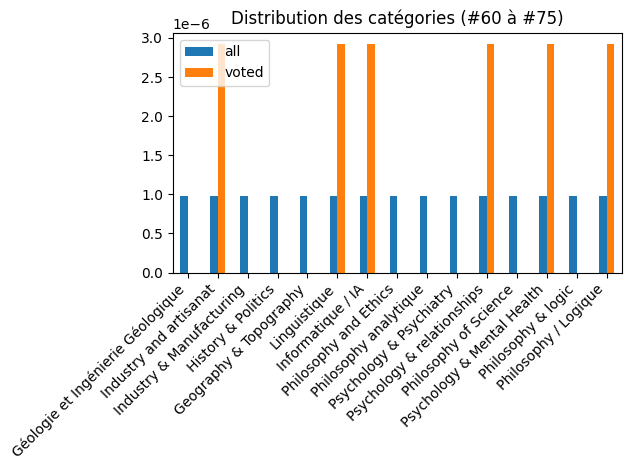

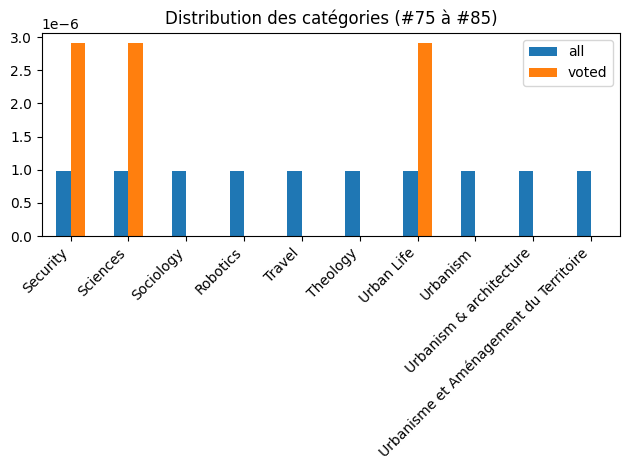

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

def get_counter(df):
    return Counter(cat for row in df["categories"] for cat in row)

counter_all = get_counter(df_conv)
counter_v = get_counter(df_conv_voted)

df_cat = pd.DataFrame({
    "all": pd.Series(counter_all),
    "voted": pd.Series(counter_v)
}).fillna(0)


# proportions
df_cat["all"] /= df_cat["all"].sum()
df_cat["voted"] /= df_cat["voted"].sum()

df_cat["diff"] = df_cat["voted"] - df_cat["all"]




# trier toutes les catégories par fréquence globale
sorted_cats = df_cat["all"].sort_values(ascending=False).index.tolist()

chunk_size = 15

for i in range(0, len(sorted_cats), chunk_size):
    chunk = sorted_cats[i:i+chunk_size]
    
    df_plot = df_cat.loc[chunk]
    
    df_plot[["all", "voted"]].plot(kind="bar")
    
    plt.title(f"Distribution des catégories (#{i} à #{i+len(chunk)})")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


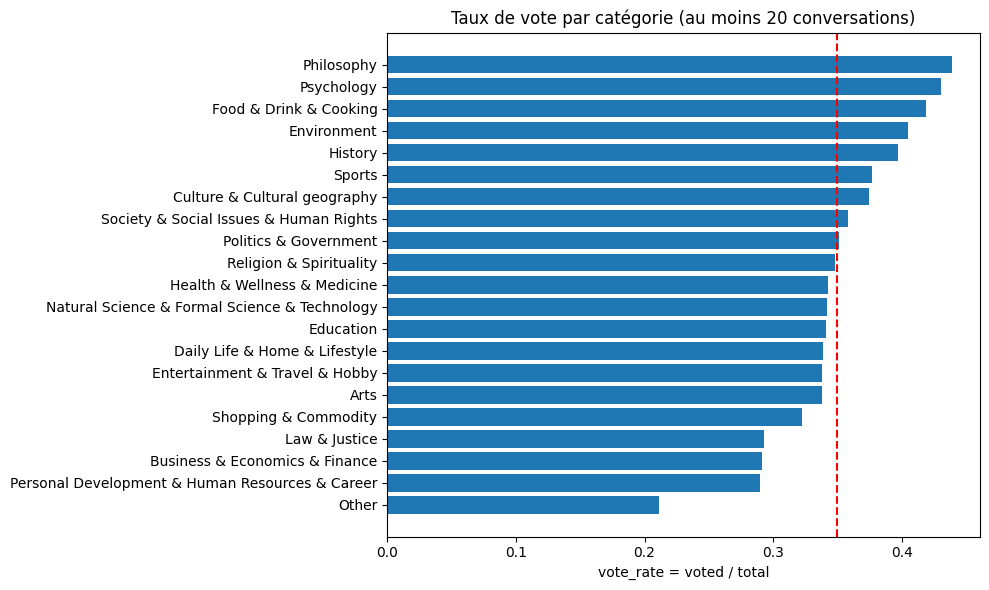

In [ ]:


def get_counter(df):
    return Counter(cat for row in df["categories"] for cat in row)

counter_all = get_counter(df_conv)
counter_v = get_counter(df_conv_voted)

df_cat = pd.DataFrame({
    "all": pd.Series(counter_all),
    "voted": pd.Series(counter_v)
}).fillna(0)




# Calcul du taux de vote
df_cat["vote_rate"] = df_cat["voted"] / df_cat["all"]

# Filtrage catégories peu représentées et tri
df_cat = df_cat[df_cat["all"] >= 20]
df_cat = df_cat.sort_values("vote_rate", ascending=False)



plt.figure(figsize=(10,6))
plt.barh(df_cat.index, df_cat["vote_rate"])
plt.gca().invert_yaxis()
plt.axvline(df_cat["vote_rate"].mean(), color="red", linestyle="--")
plt.title("Taux de vote par catégorie (au moins 20 conversations)")
plt.xlabel("vote_rate = voted / total")
plt.tight_layout()
plt.show()



On observe que le taux de vote est différent selon les catégories. Certaines comme la philosophie, la psychologie ou la cuisine sont sur-représentées tandis que le développement personnel, le droit, le business sont sous-représentées. La catégorie "other" est elle particulièrement sous-représentée au niveau des votes.

La distribution des conversations votées diffère de celle des conversations, introduisant un biais de généralisation envers les catégories les plus votées

## K de Krippendorff 

In [ ]:
# to do when done...